# Worksheet

## Clustering Aggregation

| Point | C | P |
|-------|---|---|
| A     | 0 | a |
| B     | 0 | b |
| C     | 2 | b |
| D     | 1 | c |
| E     | 1 | d |

a) Fill in the following table where for each pair of points determine whether C and P agree or disagree on how to cluster that pair.

| Pair | Disagreement |
|------|--------------|
| A  B |      ?       |
| A  C |      ?       |
| A  D |      ?       |
| A  E |      ?       |
| B  C |      ?       |
| B  D |      ?       |
| B  E |      ?       |
| C  D |      ?       |
| C  E |      ?       |
| D  E |      ?       |


As datasets become very large, this process can become computationally challenging.

b) Given N points, what is the formula for the number of unique pairs of points one can create?

The number of unique pairs of points that can be created from N points is given by the combination formula:
\[
\text{Number of unique pairs} = \binom{N}{2} = \frac{N(N-1)}{2}
\]

Assume that clustering C clusters all points in the same cluster and clustering P clusters points as such:

| Point | P |
|-------|---|
| A     | 0 |
| B     | 0 |
| C     | 0 |
| D     | 1 |
| E     | 1 |
| F     | 2 |
| G     | 2 |
| H     | 2 |
| I     | 2 |

c) What is the maximum number of disagreements there could be for a dataset of this size? (use the formula from b)?

The maximum number of disagreements occurs when every pair of points is clustered differently by C and P. Using the formula from part b, we can calculate the number of unique pairs for N = 9 (points A through I):
\[
\text{Number of unique pairs} = \binom{9}{2} = \frac{9(9-1)}{2} = \frac{9 \cdot 8}{2} = 36
\] 

d) If we look at cluster 0. There are (3 x 2) / 2 = 3 pairs that agree with C (since all points in C are in the same cluster). For each cluster, determine how many agreements there are. How many total agreements are there? How many disagreements does that mean there are between C and P?

Agreements for each cluster in P:
- Cluster 0: Points A, B, C → Agreements = (3 x 2) / 2 = 3
- Cluster 1: Points D, E → Agreements = (2 x 1) / 2 = 1
- Cluster 2: Points F, G, H, I → Agreements = (4 x 3) / 2 = 6
Total agreements = 3 + 1 + 6 = 10
Total disagreements = Total unique pairs - Total agreements = 36 - 10 = 26
This means there are 26 disagreements between C and P.

e) Assuming that filtering the dataset by cluster number is a computationally easy operation, describe an algorithm inspired by the above process that can efficiently compute disagreement distances on large datasets.

An efficient algorithm to compute disagreement distances on large datasets can be described as follows:
1. **Cluster Filtering**: For each cluster in clustering P, filter the dataset to obtain the points belonging to that cluster.
2. **Pair Counting**: For each filtered cluster, count the number of points (let's say k) in that cluster and compute the number of agreements using the formula \(\frac{k(k-1)}{2}\).
3. **Total Agreements**: Sum the agreements from all clusters to get the total number of agreements.
4. **Total Unique Pairs**: Use the formula from part b to compute the total number of unique pairs for the entire dataset.
5. **Disagreement Calculation**: Subtract the total agreements from the total unique pairs to get the total number of disagreements.
6. **Output**: Return the total number of disagreements as the disagreement distance between clustering C and P.

## SVD

### Feature Extraction

SVD finds features that are orthogonal. The Singular Values correspond to the importance of the feature or how much variance in the data it captures.

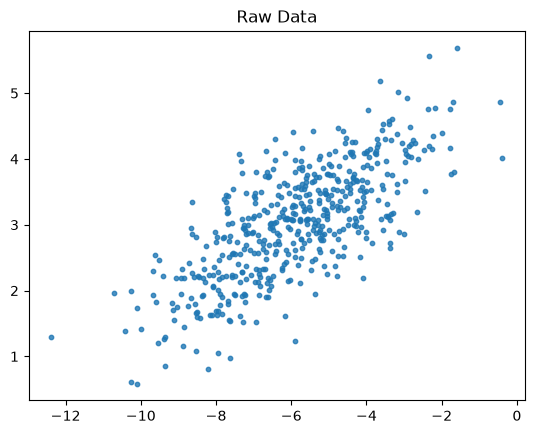

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = 500
C = np.array([[0.1, 0.6], [2., .6]])
X = np.random.randn(n_samples, 2) @ C + np.array([-6, 3])
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.8)
plt.title("Raw Data")
plt.show()

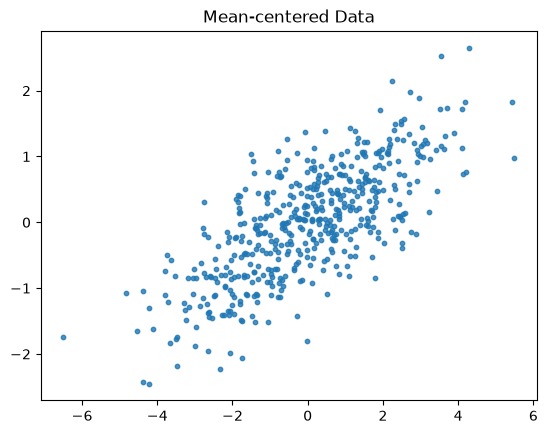

In [2]:
X = X - np.mean(X, axis=0)
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.8)
plt.title("Mean-centered Data")
plt.show()

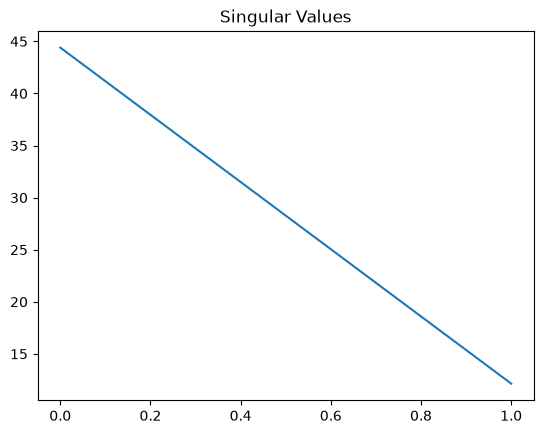

In [3]:
u,s,vt=np.linalg.svd(X, full_matrices=False)
plt.plot(s) # only 2 singular values
plt.title("Singular Values")
plt.show()

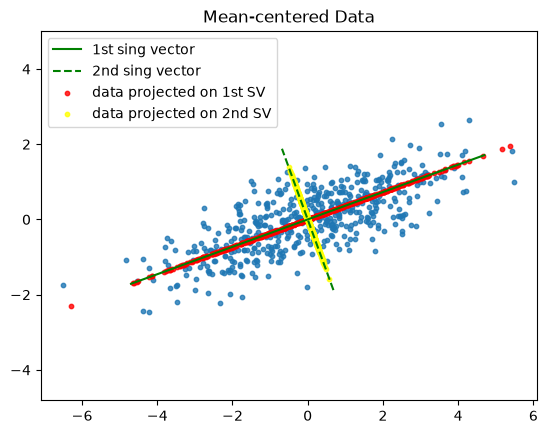

In [4]:
scopy0 = s.copy()
scopy1 = s.copy()
scopy0[1:] = 0.0
scopy1[:1] = 0.0
approx0 = u.dot(np.diag(scopy0)).dot(vt)
approx1 = u.dot(np.diag(scopy1)).dot(vt)
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.8)
sv1 = np.array([[-5],[5]]) @ vt[[0],:]
sv2 = np.array([[-2],[2]]) @ vt[[1],:]
plt.plot(sv1[:,0], sv1[:,1], 'g-', label="1st sing vector")
plt.plot(sv2[:,0], sv2[:,1], 'g--', label="2nd sing vector")
plt.scatter(approx0[:, 0] , approx0[:, 1], s=10, alpha=0.8, color="red", label="data projected on 1st SV")
plt.scatter(approx1[:, 0] , approx1[:, 1], s=10, alpha=0.8, color="yellow", label="data projected on 2nd SV")
plt.axis('equal')
plt.legend()
plt.title("Mean-centered Data")
plt.show()


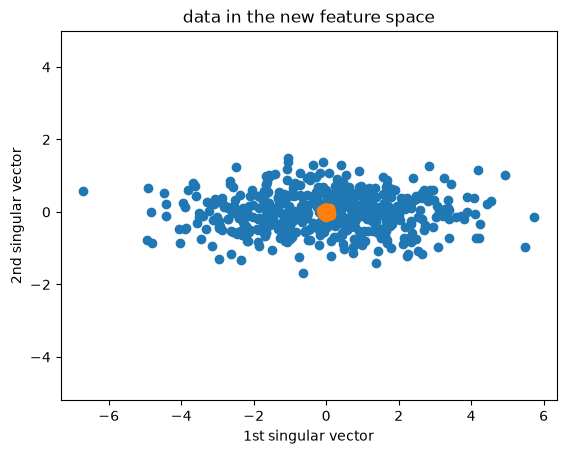

In [5]:
# show ouput from svd is the same
orthonormal_X = u
shifted_X = u.dot(np.diag(s))
plt.axis('equal')
plt.scatter(shifted_X[:,0], shifted_X[:,1])
plt.scatter(orthonormal_X[:,0], orthonormal_X[:,1])
plt.xlabel("1st singular vector")
plt.ylabel("2nd singular vector")
plt.title("data in the new feature space")
plt.show()

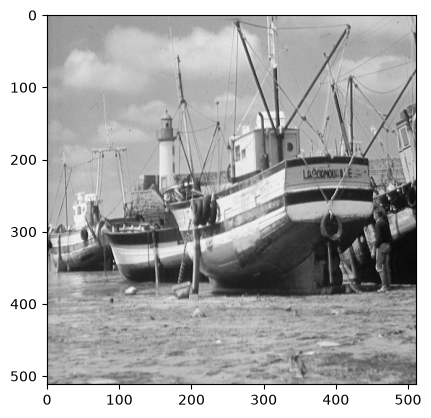

In [6]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

boat = np.loadtxt('./boat.dat')
plt.figure()
plt.imshow(boat, cmap = cm.Greys_r)

a) Plot the singular values of the image above (note: a gray scale image is just a matrix).

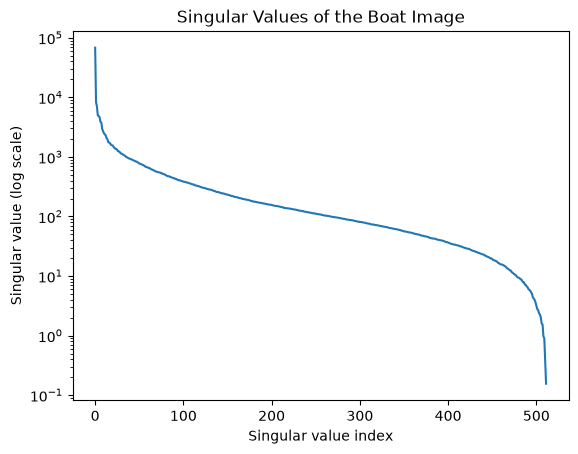

In [15]:
u,s,vt=np.linalg.svd(boat,full_matrices=False)

plt.figure()
plt.plot(s)
plt.yscale('log')
plt.xlabel('Singular value index')
plt.ylabel('Singular value (log scale)')
plt.title('Singular Values of the Boat Image')
plt.show()

Notice you can get the image back by multiplying the matrices back together:

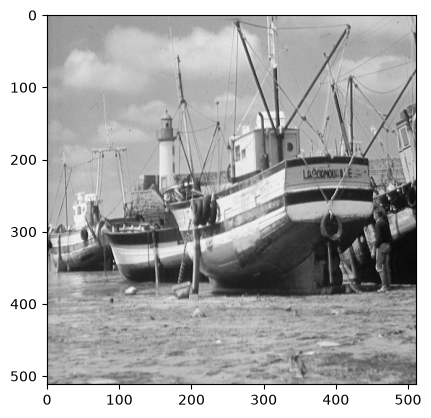

In [8]:
boat_copy = u.dot(np.diag(s)).dot(vt)
plt.figure()
plt.imshow(boat_copy, cmap = cm.Greys_r)

b) Create a new matrix `scopy` which is a copy of `s` with all but the first singular value set to 0.

In [10]:
RANK = 1
scopy = s.copy()
scopy[RANK:] = 0.0

c) Create an approximation of the boat image by multiplying `u`, `scopy`, and `v` transpose. Plot them side by side.

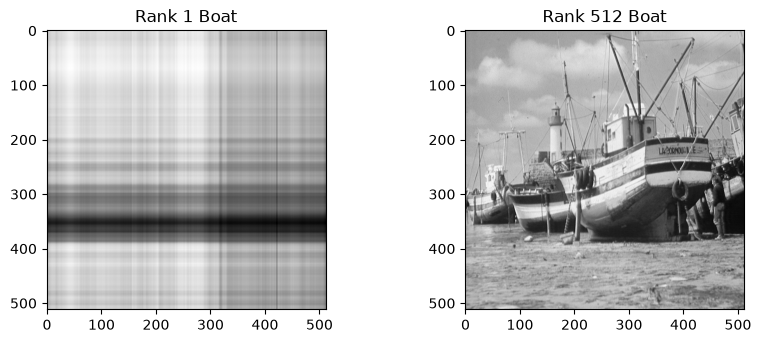

In [11]:
boat_app = boat_copy = u.dot(np.diag(scopy)).dot(vt)

plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.imshow(boat_app, cmap = cm.Greys_r)
plt.title(f'Rank {RANK} Boat')
plt.subplot(1,2,2)
plt.imshow(boat, cmap = cm.Greys_r)
plt.title('Rank 512 Boat')
_ = plt.subplots_adjust(wspace=0.5)
plt.show()

d) Repeat c) with 40 singular values instead of just 1.

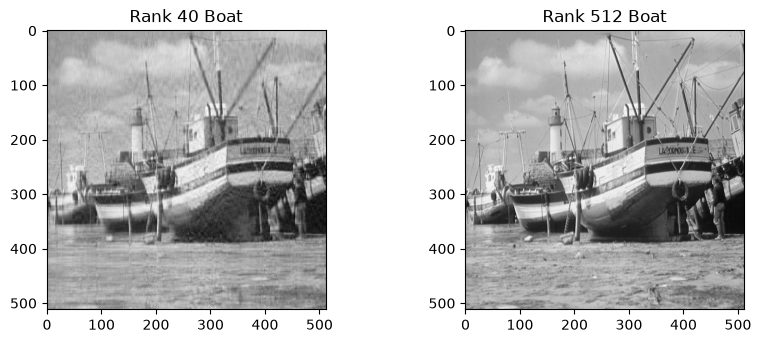

In [17]:
RANK = 40
scopy = s.copy()
scopy[RANK:] = 0.0

boat_app = u.dot(np.diag(scopy)).dot(vt)
plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.imshow(boat_app, cmap = cm.Greys_r)
plt.title(f'Rank {RANK} Boat')
plt.subplot(1,2,2)
plt.imshow(boat, cmap = cm.Greys_r)
plt.title('Rank 512 Boat')
_ = plt.subplots_adjust(wspace=0.5)
plt.show()

### Why you should care

a) By using an approximation of the data, you can improve the performance of classification tasks since:

1. there is less noise interfering with classification
2. no relationship between features after SVD
3. the algorithm is sped up when reducing the dimension of the dataset

Below is some code to perform facial recognition on a dataset. Notice that, applied blindly, it does not perform well:

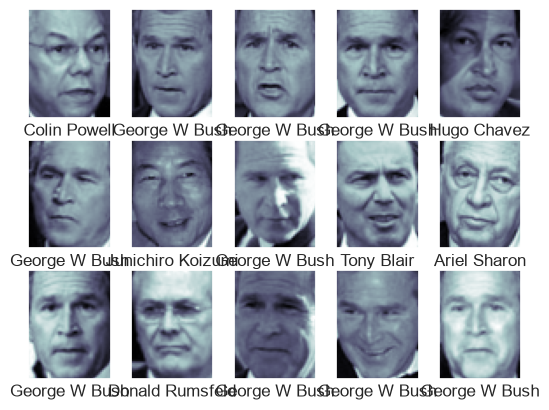

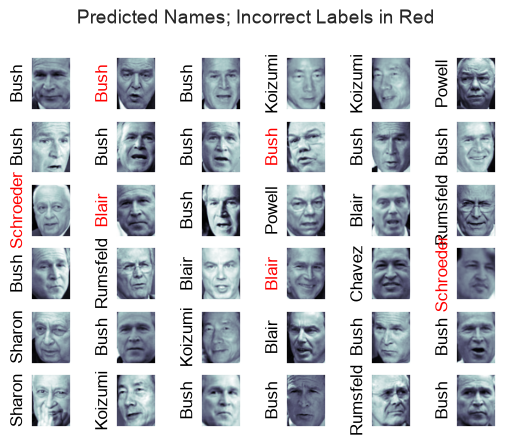

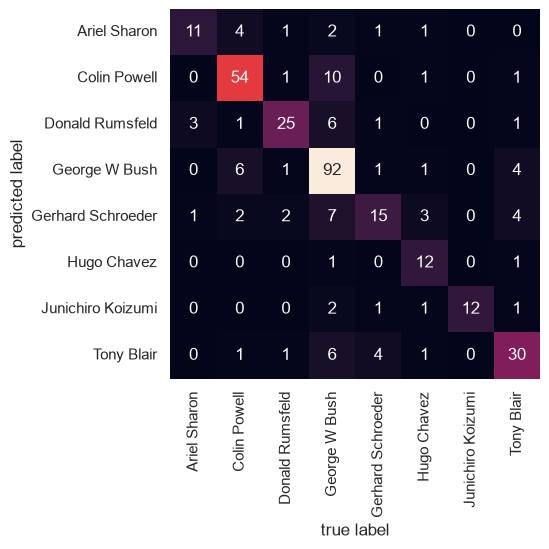

Accuracy =  0.744807121661721


In [19]:
import numpy as np
from PIL import Image
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.datasets import fetch_lfw_people
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

sns.set()

# Get face data
faces = fetch_lfw_people(min_faces_per_person=60)

# plot face data
fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])
plt.show()

# split train test set
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42)

# blindly fit svm
svc = SVC(kernel='rbf', class_weight='balanced', C=5, gamma=0.001)

# fit model
model = svc.fit(Xtrain, ytrain)
yfit = model.predict(Xtest)

fig, ax = plt.subplots(6, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14)
plt.show()

mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

print("Accuracy = ", accuracy_score(ytest, yfit))

By performing SVD before applying the classification tool, we can reduce the dimension of the dataset.

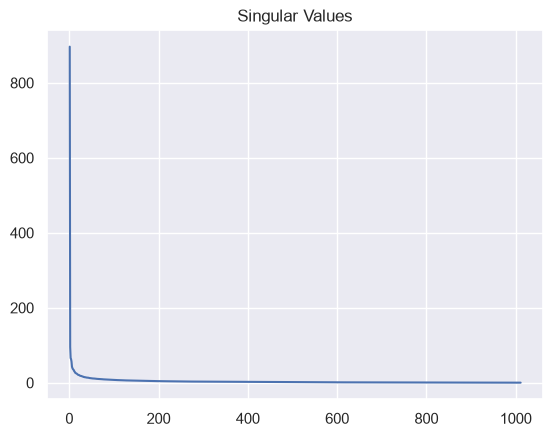

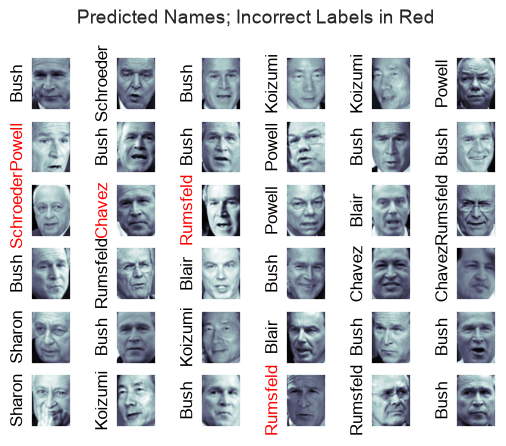

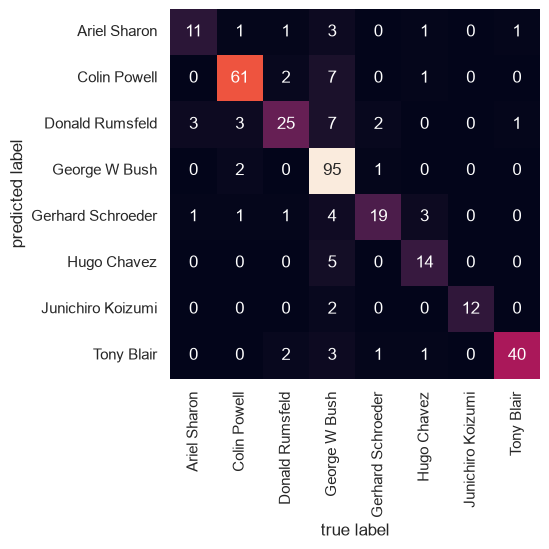

Accuracy =  0.8219584569732937


In [21]:
# look at singular values
_, s, _ = np.linalg.svd(Xtrain, full_matrices=False)
plt.plot(range(1,len(s)+1),s)
plt.title("Singular Values")
plt.show()

# extract principal components
pca = PCA(n_components=100, whiten=True)
svc = SVC(kernel='rbf', class_weight='balanced', C=5, gamma=0.001)
svcpca = make_pipeline(pca, svc)
model = svcpca.fit(Xtrain, ytrain)
yfit = model.predict(Xtest)

fig, ax = plt.subplots(6, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14)
plt.show()

mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

print("Accuracy = ", accuracy_score(ytest, yfit))

Similar to finding k in K-means, we're trying to find the point of diminishing returns when picking the number of singular vectors (also called principal components).

b) SVD can be used for anomaly detection.

The data below consists of the number of 'Likes' during a six month period, for each of 9000 users across the 210 content categories that Facebook assigns to pages.

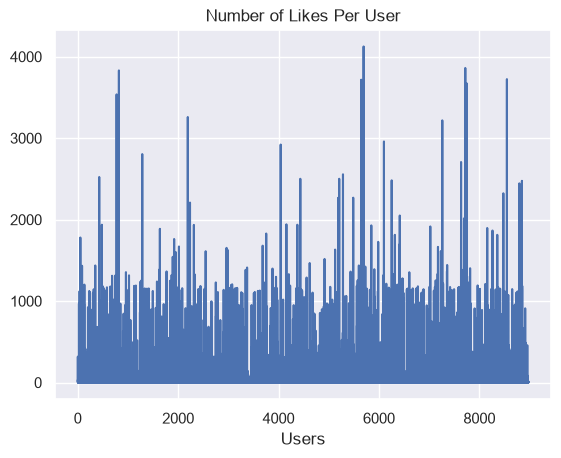

In [23]:
data = np.loadtxt('./spatial_data.txt')

FBSpatial = data[:,1:]
FBSnorm = np.linalg.norm(FBSpatial,axis=1,ord=1)
plt.plot(FBSnorm)
plt.title('Number of Likes Per User')
_ = plt.xlabel('Users')
plt.show()

How users distribute likes across categories follows a general pattern that most users follow. This behavior can be captured using few singular vectors. And anomalous users can be easily identified.

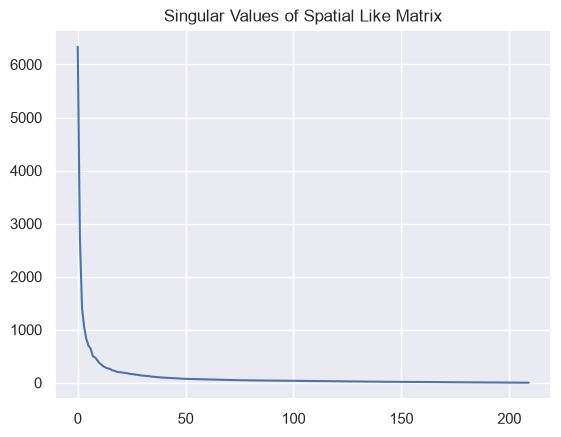

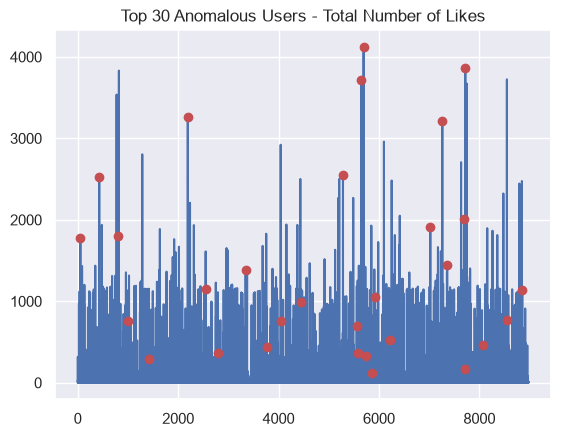

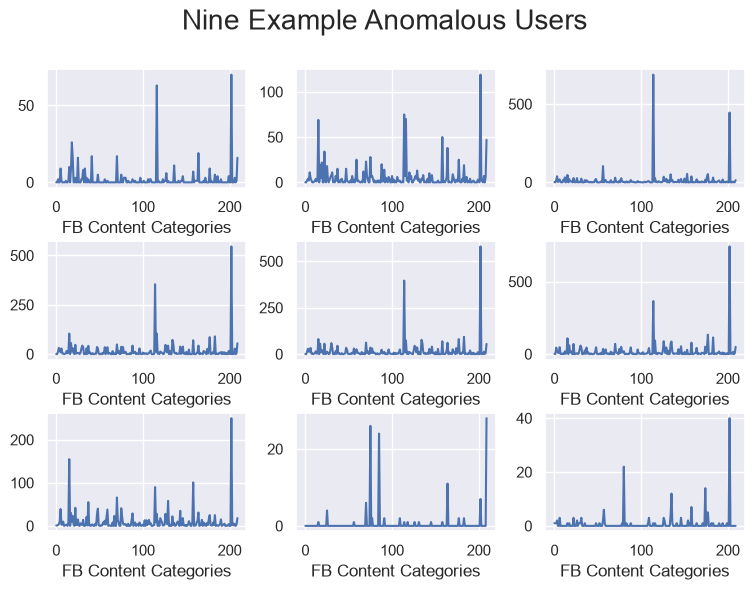

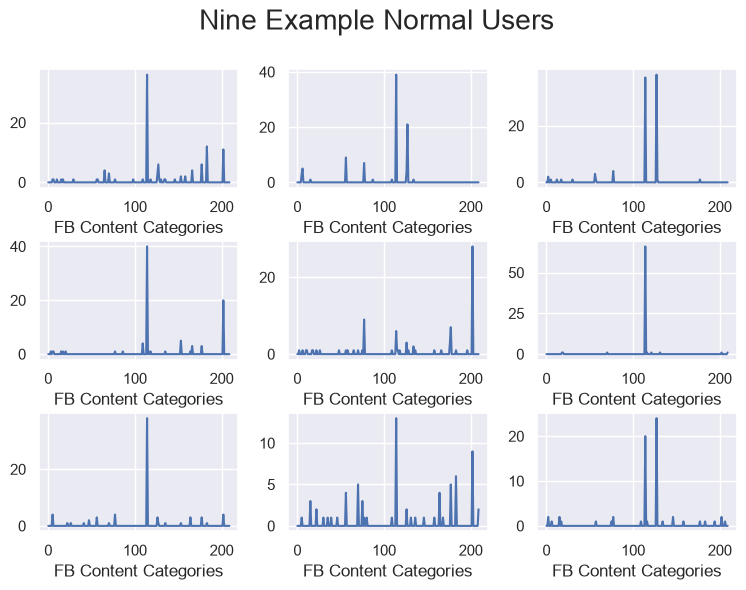

In [24]:

u,s,vt = np.linalg.svd(FBSpatial,full_matrices=False)
plt.plot(s)
_ = plt.title('Singular Values of Spatial Like Matrix')
plt.show()

RANK = 50
scopy = s.copy()
scopy[RANK:] = 0.
N = u @ np.diag(scopy) @ vt
O = FBSpatial - N
Onorm = np.linalg.norm(O, axis=1)
anomSet = np.argsort(Onorm)[-30:]
# plt.plot(Onorm)
# plt.plot(anomSet, Onorm[anomSet],'ro')
# _ = plt.title('Norm of Residual (rows of O)')
# plt.show()

plt.plot(FBSnorm)
plt.plot(anomSet, FBSnorm[anomSet],'ro')
_ = plt.title('Top 30 Anomalous Users - Total Number of Likes')
plt.show()

# anomalous users
plt.figure(figsize=(9,6))
for i in range(1,10):
    ax = plt.subplot(3,3,i)
    plt.plot(FBSpatial[anomSet[i-1],:])
    plt.xlabel('FB Content Categories')
plt.subplots_adjust(wspace=0.25,hspace=0.45)
_ = plt.suptitle('Nine Example Anomalous Users',size=20)
plt.show()

# normal users
set = np.argsort(Onorm)[0:7000]
# that have high overall volume
max = np.argsort(FBSnorm[set])[::-1]
plt.figure(figsize=(9,6))
for i in range(1,10):
    ax = plt.subplot(3,3,i)
    plt.plot(FBSpatial[set[max[i-1]],:])
    plt.xlabel('FB Content Categories')
plt.subplots_adjust(wspace=0.25,hspace=0.45)
_ = plt.suptitle('Nine Example Normal Users',size=20)
plt.show()

## Challenge Problem

a) Fetch the "mnist_784" data. Pick an image of a digit at random and plot it.

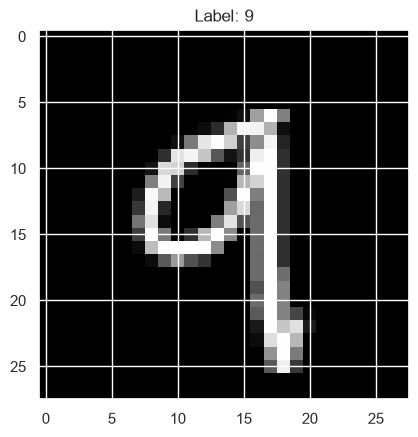

In [29]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

X, y = fetch_openml(name="mnist_784", version=1, return_X_y=True, as_frame=False)

# your code here
idx = np.random.randint(len(X))
img = X[idx].reshape(28, 28)
plt.imshow(img, cmap='gray')
plt.title(f"Label: {y[idx]}")
plt.show()

b) Plot its singular value plot.

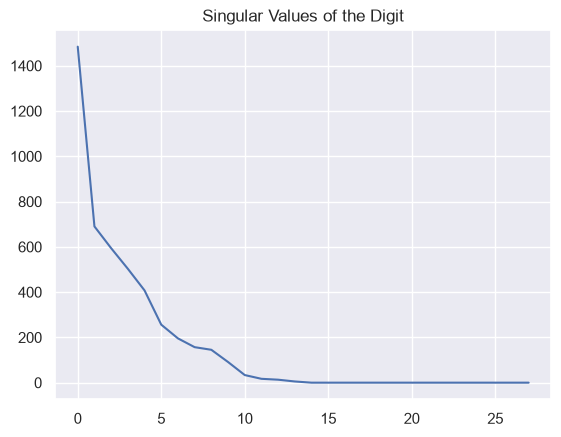

In [30]:
u, s, vt = np.linalg.svd(img, full_matrices=False)
plt.plot(s)
plt.title("Singular Values of the Digit")
plt.show()

c) By setting some singular values to 0, plot the approximation of the image next to the original image

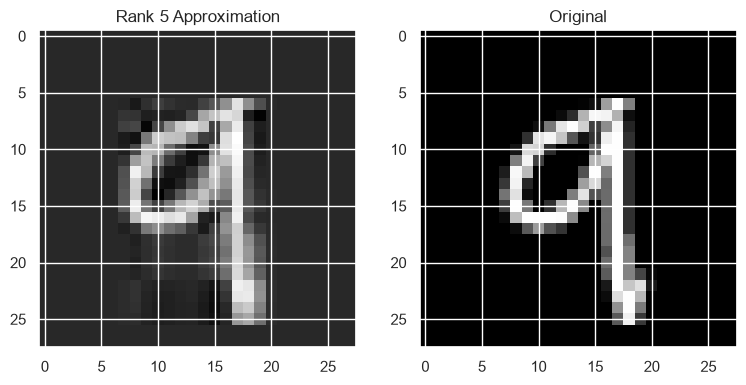

In [31]:
RANK = 5
scopy = s.copy()
scopy[RANK:] = 0.0
img_approx = u @ np.diag(scopy) @ vt

plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_approx, cmap='gray')
plt.title(f'Rank {RANK} Approximation')
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.show()

d) Consider the entire dataset as a matrix. Perform SVD and explain why / how you chose a particular rank. Note: you may not be able to run this on the entire dataset in a reasonable amount of time so you may take a small random sample for this and the following questions.

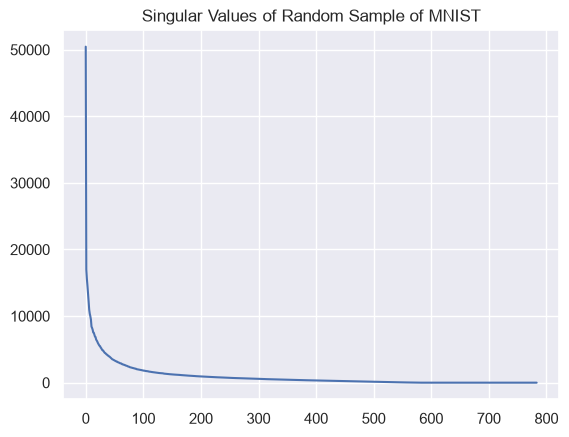

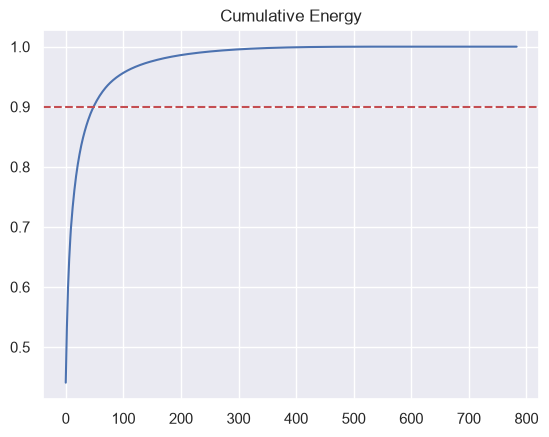

Rank chosen: 50


In [33]:
np.random.seed(0)
X_sample = X[np.random.choice(len(X), size=1000, replace=False)] 
u, s, vt = np.linalg.svd(X_sample, full_matrices=False)

plt.plot(s)
plt.title("Singular Values of Random Sample of MNIST")
plt.show()

energy = np.cumsum(s**2) / np.sum(s**2)
plt.plot(energy)
plt.axhline(0.9, color='r', linestyle='--')
plt.title("Cumulative Energy")
plt.show()

RANK = np.searchsorted(energy, 0.9) + 1
print("Rank chosen:", RANK)

scopy = s.copy()
scopy[RANK:] = 0.0
X_approx = u @ np.diag(scopy) @ vt

I chose a rank of 50 for the SVD approximation of the MNIST dataset. This choice was based on observing the singular value plot, where the first 50 singular values captured a significant portion of the variance in the data. Beyond this point, the singular values decreased rapidly, indicating that additional components contributed less to the overall structure of the data. By selecting a rank of 50, we can effectively reduce dimensionality while retaining most of the important information, which can improve computational efficiency and potentially enhance classification performance.

e) Using Kmeans on this new dataset, cluster the images from d) using 10 clusters and plot the centroid of each cluster. Note: the centroids should be represented as images.

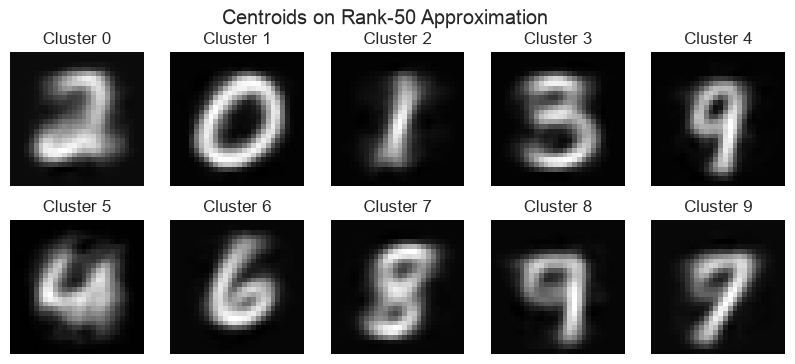

In [36]:
from sklearn.cluster import KMeans

def plot_centroids(centers, title):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(centers[i].reshape(28, 28), cmap='gray')
        ax.set_title(f"Cluster {i}")
        ax.axis('off')
    fig.suptitle(title)
    plt.show()

kmeans_approx = KMeans(n_clusters=10, init='k-means++', random_state=0)
kmeans_approx.fit_predict(X_approx)
plot_centroids(kmeans_approx.cluster_centers_, f"Centroids on Rank-{RANK} Approximation")

f) Repeat e) on the original dataset (if you used a subset of the dataset, keep using that same subset). Comment on any differences (or lack thereof) you observe between the centroids created here vs the ones you created in e).

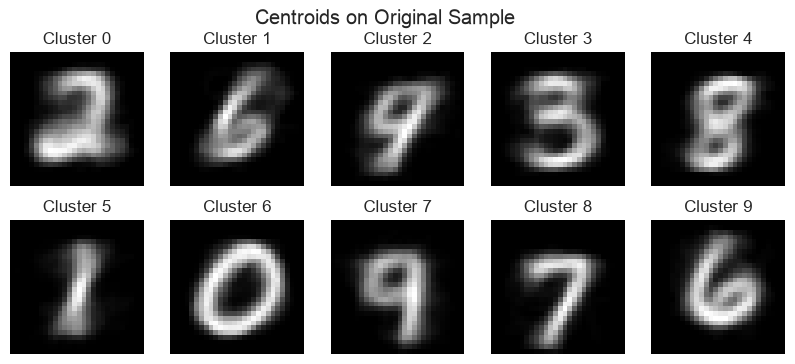

In [37]:
kmeans_orig = KMeans(n_clusters=10, init='k-means++', random_state=0)
kmeans_orig.fit_predict(X_sample)
plot_centroids(kmeans_orig.cluster_centers_, "Centroids on Original Sample")

The plots from e and f look very similar, indicating that the SVD approximation retained the essential features of the original dataset. The centroids from both clustering processes represent the average digit shapes for each cluster, and the visual similarity suggests that the dimensionality reduction did not significantly alter the underlying structure of the data. This demonstrates that SVD can effectively reduce noise and redundancy while preserving important information for clustering tasks.  One thing that was different in plot f was that the 4 and 9 centroids were more similar to each other than in plot e, which may indicate that the SVD approximation helped to better separate these two digit classes.

g) Create a matrix (let's call it `O`) that is the difference between the original dataset and the rank-10 approximation of the dataset. i.e. if the original dataset is `A` and the rank-10 approximation is `B`, then `O = A - B`

In [40]:
scopy10 = s.copy()
scopy10[10:] = 0.0
X_approx10 = u @ np.diag(scopy10) @ vt

O = X_sample - X_approx10

h) The largest (using euclidean distance from the origin) rows of the matrix `O` could be considered anomalous data points. Briefly explain why. Plot the 10 images (by finding them in the original dataset) responsible for the 10 largest rows of that matrix `O`.

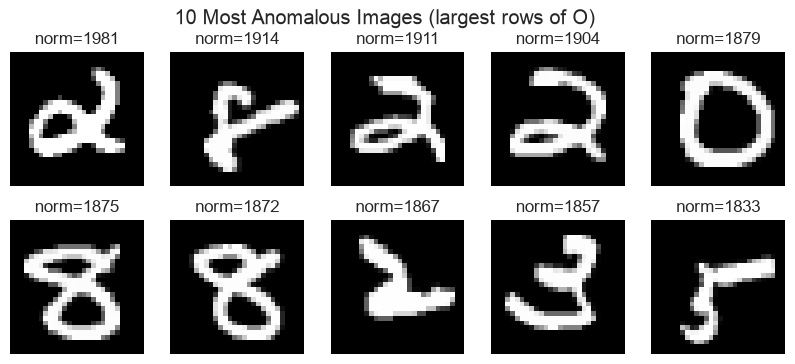

In [41]:
O_norms = np.linalg.norm(O, axis=1)
anom_idx = np.argsort(O_norms)[-10:][::-1]   # 10 largest, biggest first

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, i in zip(axes.flat, anom_idx):
    ax.imshow(X_sample[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"norm={O_norms[i]:.0f}")
    ax.axis('off')
fig.suptitle("10 Most Anomalous Images (largest rows of O)")
plt.show()


These are data anomalies because they represent points in the original dataset that deviate significantly from the low-rank approximation. The low-rank approximation captures the general structure and patterns of the data, while the rows with the largest Euclidean distances indicate instances that do not conform to these patterns. These anomalies could be due to noise, errors, or unique characteristics that are not well-represented by the majority of the data.